In [33]:
# Purpose:
# Reuse the validated LIF neuron dynamics from Exercise 0
# and import the required libraries again

# Source of Code and Justification:
# Exercise 1 keeps the same neuron model as Exercise 0:
# tau_m * du/dt = -u + R * I_total.

# Approach:
# - Add project root again
# - Import libraries again (NumPy, Matplotlib)
# - Import sparse-matrix tools for recurrent connectivity (csr_matrix)
# - Reuse LIF functions from Exercise 0

# What to say in Report:
# “For Exercise 1, we kept the same LIF membrane dynamics as in Exercise 0,
# while extending the model with sparse recurrent excitatory and inhibitory
# synaptic connectivity.”

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Define figures directory
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.lif import lif_euler_step, simulate_lif_population, lif_theoretical_fi

In [34]:
# Purpose:
# Initialize all Exercise 1 network, neuron, synaptic, noise, and simulation-time parameters
# before implementing recurrent E/I dynamics.

# Source of Code and Justification:
# Parameters are taken directly from the Exercise 1 statement in the project :
# NE = 1000, gamma = 0.25, p = 0.02, g = 5, J = 45 pC, tau_delay = 2 ms.
# The single-neuron LIF parameters are unchanged from Exercise 0 :
# theta = 20 mV, u_reset = -10 mV, R = 1 MOhm, dt = 0.5 ms, tau_m = 20 ms.
# Background input remains Poisson with n_bg = 25, as specified for subsequent exercises.

# Approach:
# - Define excitatory/inhibitory population sizes and total neuron count
# - Compute connections KE and KI with connection fraction p
# - Set recurrent synaptic strength and delay parameters
# - Reuse validated LIF neuron parameters from Ex.0
# - Keep stochastic background input settings unchanged
# - Define discrete time vector

# What to say in Report:
# “We initialized Exercise 1 using the assignment’s network and neuron parameters.
# Population sizes and sparse connections were set from (NE, gamma, p), while synaptic
# interactions are from (J, g, tau_delay). The LIF and background-noise parameters were kept
# identical to Exercise 0.”


# Network size from ex 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

# Connectivity from ex 1
p = 0.02
KE = int(p * NE)
KI = int(p * NI)

# Synaptic parameters from ex 1
J = 45.0          # pC
g = 5.0
tau_delay = 2.0   # ms

# LIF parameters for a neuron (same as Ex.0)
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Background input parameters (same as Ex.0)
n_bg = 25.0       # mean Poisson events per time step
bg_scale = 1.0    # nA per event

# Time (same as Ex.0.2)
T_ms = 100.0         # ms 
n_steps = int(T_ms / dt)
time = np.arange(n_steps) * dt

Exercise 1.2 f-I sweep: 100%|██████████| 13/13 [00:01<00:00, 11.89it/s]


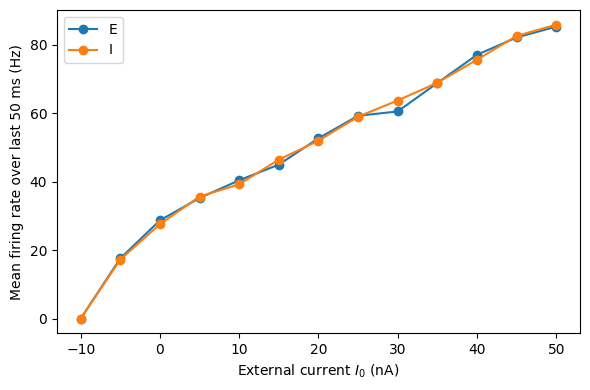

In [35]:
# Purpose:
# Create the sparse matrix W for the recurrent network (Exercise 1.1)
# and reproduce Exercise 1.2 by sweeping constant external current I0.
# For each I0, we measure excitatory and inhibitory population firing rates.

# Source of Code and Justification:
# Exercise 1.2 asks for f-I curves of E and I populations on the same plot,
# using the same procedure as Exercise 0.2:
# simulate for T = 100 ms and report mean firing rates averaged over the last 50 ms.
# The recurrent network uses the sparse weight matrix W generated in Exercise 1.1,
# with delayed synaptic feedback and Poisson background input.

# Approach:
# - Fix one sparse recurrent connectivity matrix W across all current values.
# - Sweep constant external current I0 from -10 nA to 50 nA.
# - For each I0, simulate the recurrent E/I network for T_ms = 100 ms.
# - Use independent Poisson background realizations for each I0.
# - Compute mean firing rates separately for E and I over [50, 100) ms.
# - Plot both f-I curves and save the figure.

# What to say in Report:
# “For Exercise 1.2, we measured population f-I curves for excitatory and
# inhibitory neurons under identical constant external input. A single sparse
# recurrent connectivity matrix was fixed across currents, so changes in firing
# rate reflect changes in external drive rather than graph variability. The E
# and I curves overlap closely, supporting an excitation-inhibition balanced regime.”

from tqdm import tqdm
from src.connectivity import generate_sparse_connectivity
from src.ei_unit import simulate_population_exc_inh, population_rate_hz

W = generate_sparse_connectivity(NE, NI, KE, KI, J, g, seed=1)

rng = np.random.default_rng(0)
I_values = np.arange(-10.0, 55.0, 5.0)

rates_E = []
rates_I = []

for i0 in tqdm(I_values, desc="Exercise 1.2 f-I sweep"):
    sim_rng = np.random.default_rng(rng.integers(0, 2**32 - 1))

    U, S = simulate_population_exc_inh(
        W=W,
        NE=NE,
        I0_const_nA=float(i0),
        T_ms=T_ms,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=sim_rng,
    )

    rE = population_rate_hz(S, slice(0, NE), dt, 50.0, T_ms)
    rI = population_rate_hz(S, slice(NE, NE + NI), dt, 50.0, T_ms)

    rates_E.append(rE)
    rates_I.append(rI)

plt.figure(figsize=(6, 4))
plt.plot(I_values, rates_E, "o-", label="E")
plt.plot(I_values, rates_I, "o-", label="I")
plt.xlabel("External current $I_0$ (nA)")
plt.ylabel("Mean firing rate over last 50 ms (Hz)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex1_2_fi_curve_EI.png", dpi=300)
plt.show()

simulate different g (I0=0): 100%|██████████| 11/11 [00:03<00:00,  3.00it/s]


g=1.0 -> rate_E =500.18 Hz, rate_I =500.40 Hz
g=1.5 -> rate_E =225.82 Hz, rate_I =225.44 Hz
g=2.0 -> rate_E =109.44 Hz, rate_I =108.40 Hz
g=2.5 -> rate_E =70.40 Hz, rate_I =70.40 Hz
g=3.0 -> rate_E =52.18 Hz, rate_I =51.68 Hz
g=3.5 -> rate_E =38.66 Hz, rate_I =38.88 Hz
g=4.0 -> rate_E =37.02 Hz, rate_I =36.24 Hz
g=4.5 -> rate_E =31.32 Hz, rate_I =32.08 Hz
g=5.0 -> rate_E =24.96 Hz, rate_I =26.48 Hz
g=5.5 -> rate_E =25.50 Hz, rate_I =24.72 Hz
g=6.0 -> rate_E =20.96 Hz, rate_I =20.56 Hz


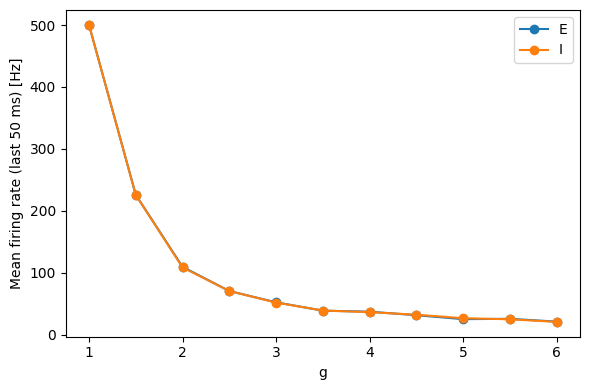

In [36]:
# Purpose:
# Determine the critical value of the parameter g required to stabilize the network. 
# We aim to identify the "inhibition-dominated" regime where recurrent activity 
# is effectively dampened by inhibitory neurons, preventing an explosion of the 
# firing rate.

# Source of Code and Justification:
# The implementation here is required by Ex 1.4 in the project instructions, which asks us to 
# determine the condition on g for the network to be "inhibition-dominated. The calculations of
# the mean firing rate for every g value allow to plot a f-g curve to visualize the transition 
# from excitation-dominated to inhibition-dominated regimes, and report the results for the condition on g." 


# Approach:
#1. Initialize a sim_data dictionary to store potentials and spikes for each value of g.
#2. For each g, generate a new sparse connectivity matrix and run the LIF simulation.
#3. Extract the mean firing rates for both Excitatory (E) and Inhibitory (I) populations.
#4. Plot the f-g curve to visualize the drop in activity as inhibition becomes dominant.

# What to say in Report:
# The resulting graph reveals an abrupt transition around g = 4.0. For g < 4.0: 
# The firing rate is extremely high (saturation). For g > 4.0: Activity drops and inhibition is strong 
# enough to counterbalance excitation.
# (The resulting graph shows that when g is too small, the network becomes excitation-dominated 
# and firing rates are very high. 
# For larger g, inhibition is strong enough to suppress runaway activity.)


g_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]  # store different g values
I0_fixed = 0.0
T_ms = 100.0

rng = np.random.default_rng(0)
sim_data = {}  

for g_test in tqdm(g_values, desc="simulate different g (I0=0)"):

    W = generate_sparse_connectivity(NE, NI, KE, KI, J, g_test, seed=1)  # calculate W for each g values
    sim_rng = np.random.default_rng(rng.integers(0, 2**32 - 1))

    U, S = simulate_population_exc_inh(
        W=W,
        NE=NE,
        I0_const_nA=I0_fixed,
        T_ms=T_ms,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=sim_rng,
    )

    sim_data[g_test] = {"U": U, "S": S}  # store results for each g value


rates_g = {}

for g_test in g_values:

    S = sim_data[g_test]["S"]

    rate_E = population_rate_hz(S, slice(0, NE), dt, 50.0, T_ms)
    rate_I = population_rate_hz(S, slice(NE, NE + NI), dt, 50.0, T_ms)

    rates_g[g_test] = {"rate_E_Hz": rate_E, "rate_I_Hz": rate_I}
    print(f"g={g_test:.1f} -> rate_E ={rates_g[g_test]['rate_E_Hz']:.2f} Hz, rate_I ={rates_g[g_test]['rate_I_Hz']:.2f} Hz")

rate_E_list = [rates_g[g_test]["rate_E_Hz"] for g_test in g_values]
rate_I_list = [rates_g[g_test]["rate_I_Hz"] for g_test in g_values]

plt.figure(figsize=(6,4))
plt.plot(g_values, rate_E_list, "o-", label="E")
plt.plot(g_values, rate_I_list, "o-", label="I")
plt.xlabel("g")
plt.ylabel("Mean firing rate (last 50 ms) [Hz]")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex1_4_fg_curve_EI.png", dpi=300)
plt.show()

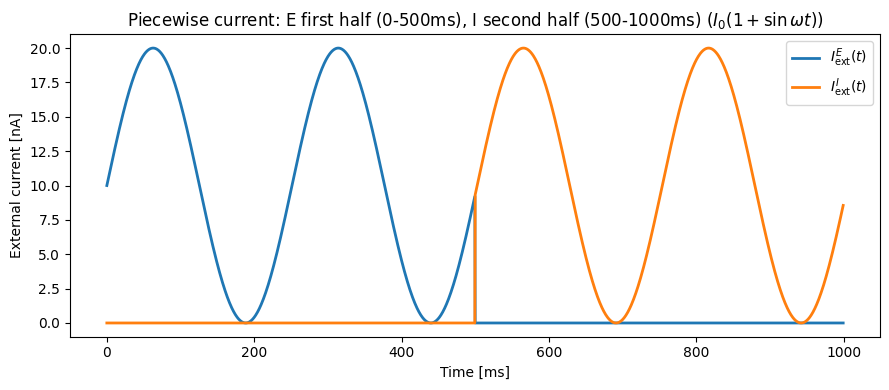

In [37]:
# Purpose:
# Construct external currents varying over time required for Exercise 1.5, where excitatory and inhibitory
# populations receive sinusoidal drive in alternating time windows.

# Source of Code and Justification:
# Exercise 1.5 specifies piecewise external inputs:
# I_ext_E = I0(1 + sin(ωt)) for 0 ≤ t < 500 ms, else 0
# I_ext_I = 0 for 0 ≤ t < 500 ms, else I0(1 + sin(ωt))
# with I0 = 10 nA and ω = 25 rad/s, over T = 1000 ms.
# Because ω is given in rad/s, time must be converted from ms to seconds inside the sine again.

# Approach:
# - Use the same approach in ex 0.1
# - Apply conditions on time to populate separate I_ext_E(t) and I_ext_I(t).
# Expand these population-level currents into a (n_steps × N) matrix I_ext:
#   all excitatory neurons share I_ext_E and all inhibitory neurons share I_ext_I.
# - Plot I_ext_E and I_ext_I vs time to verify the switching at t = 500 ms.

# What to say in Report:
# “We implemented the sinusoidal external drive I0(1 + sin(ωt)) to the excitatory population during the 
# first 500 ms and to the inhibitory population during the second 500 ms.
# The resulting population currents were broadcast to all neurons within each population to form the full
# external input I_ext.”

T_ms = 1000.0
I0 = 10.0      # nA
omega = 25.0   # rad/s

n_steps = int(T_ms / dt)
time_ms = np.arange(n_steps) * dt
time_s = time_ms / 1000.0

I_sinus = I0 * (1.0 + np.sin(omega * time_s))

# E driven 0–500 ms, I driven 500–1000 ms

I_ext_E = np.zeros(n_steps)
I_ext_I = np.zeros(n_steps)
cond_E = time_ms < 500.0
cond_I = ~cond_E
I_ext_E[cond_E] = I_sinus[cond_E]
I_ext_I[cond_I] = I_sinus[cond_I]

# all neurons in each population
I_ext = np.zeros((n_steps, N))
I_ext[:, :NE] = I_ext_E[:, None]
I_ext[:, NE:] = I_ext_I[:, None]

# plot the current
plt.figure(figsize=(9, 4))
plt.plot(time_ms, I_ext_E, label=r"$I_{\mathrm{ext}}^{E}(t)$", color="tab:blue", lw=2)
plt.plot(time_ms, I_ext_I, label=r"$I_{\mathrm{ext}}^{I}(t)$", color="tab:orange", lw=2)
plt.xlabel("Time [ms]")
plt.ylabel("External current [nA]")
plt.title("Piecewise current: E first half (0-500ms), I second half (500-1000ms) ($I_0(1+\\sin\\omega t)$)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex1_5_1_piecewise_current.png", dpi=300)
plt.show()

In [38]:
# Purpose:
# Run the full recurrent E/I network simulation for Exercise 1.5 using the time-varying
# external input I_ext

# Source of Code and Justification:
# Exercise 1.5 requires simulating the same network as in Exercise 1.2 but with piecewise external currents
# I_ext^E(t) and I_ext^I(t) given by Equations (6)–(7) over T = 1000 ms.
# The simulation must therefore use a vector I_ext[k, :] rather than
# a single constant I0 for all time. That's why we added a new argument to the simulate function (I_ext_t).

# Approach:
# - Call simulate_population_exc_inh with I_ext_t

# What to say in Report:
# “We simulated the sparse recurrent E/I network for T = 1000 ms using the Exercise 1.5 stimulation
# protocol. The simulation function was extended to accept a full time-dependent external input matrix
# I_ext_t, allowing excitatory and inhibitory populations to receive different currents over time.”

W = generate_sparse_connectivity(NE, NI, KE, KI, J, g, seed=1)
rng = np.random.default_rng(0)

U, S = simulate_population_exc_inh(
    W=W,
    NE=NE,
    I0_const_nA=0.0,
    T_ms=T_ms,
    dt=dt,
    tau_m=tau_m,
    R=R,
    theta=theta,
    u_reset=u_reset,
    tau_delay_ms=tau_delay,
    n_bg=n_bg,
    bg_scale=bg_scale,
    rng=rng,
    I_ext_t=I_ext
)

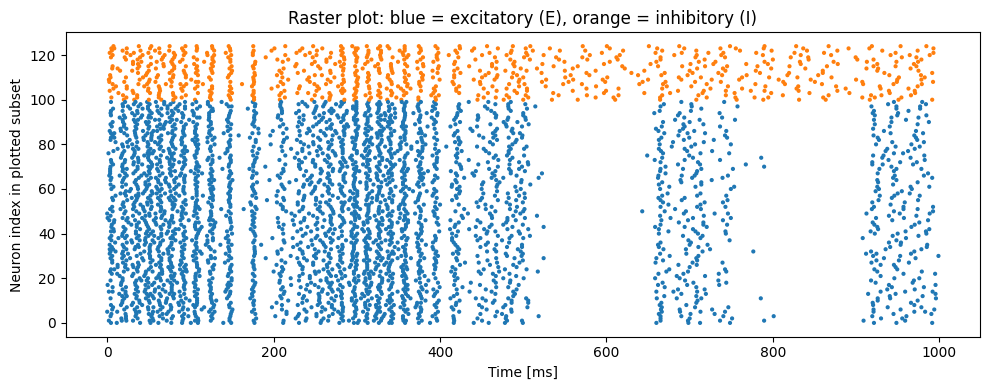

In [39]:
# Purpose:
# Visualize Exercise 1.5 network spiking activity with a raster plot
# distinguishing excitatory (E) and inhibitory (I) neurons.

# Source of Code and Justification:
# Exercise 1.5 requests a raster plot over the full T = 1000 ms simulation,
# showing spikes from a subset of excitatory and inhibitory neurons.

# Approach:
# - Randomly sample 100 excitatory neuron indices from [0, NE)
#   and 25 inhibitory neuron indices from [NE, N).
# - Extract spike coordinates from the spike matrix S.
# - Convert timestep indices into milliseconds using k * dt.
# - Display excitatory spikes in blue and inhibitory spikes in orange.

# What to say in Report:
# “We generated a raster plot for a random subset of 100 excitatory and
# 25 inhibitory neurons over the full 1000 ms simulation. Excitatory spikes
# are shown in blue and inhibitory spikes in orange. During the first half
# of the simulation, excitatory neurons receive the sinusoidal external drive,
# producing strong E activity. After 500 ms, the drive switches to the
# inhibitory population, changing the network activity pattern while recurrent
# interactions maintain activity in both populations.”

exc_idx = rng.choice(np.arange(NE), size=100, replace=False)
inh_idx = rng.choice(np.arange(NE, NE + NI), size=25, replace=False)

idx = np.r_[exc_idx, inh_idx]

spike_steps, neuron_pos = np.where(S[:, idx] > 0)

plt.figure(figsize=(10, 4))

plt.scatter(
    spike_steps * dt,
    neuron_pos,
    s=4,
    c=np.where(neuron_pos < 100, "tab:blue", "tab:orange")
)

plt.title("Raster plot: blue = excitatory (E), orange = inhibitory (I)")
plt.xlabel("Time [ms]")
plt.ylabel("Neuron index in plotted subset")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex1_5_2_raster_plot_EI.png", dpi=300)
plt.show()

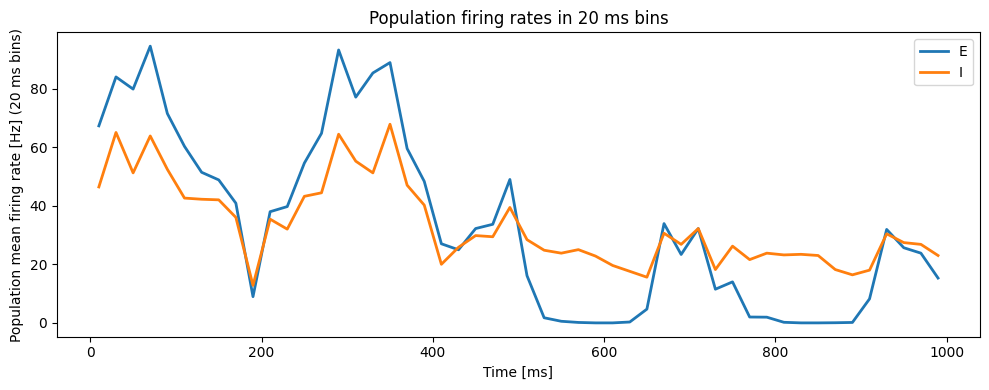

In [40]:
# Purpose:
# Compute and plot excitatory vs inhibitory population mean firing rates over time
# using non-overlapping 20 ms time bins.

# Source of Code and Justification:
# Exercise 1.5 asks for a single plot of E and I population firing rates with the same color coding 
# as the raster, combining activity in bins of 20 ms and normalizing to express rates in Hz.

# Approach:
# - Define bin edges from 0 to T_ms in steps of 20 ms.
# - For each bin, convert millisecond boundaries to timestep indices t0 and t1. Then, we count spikes.
# - Convert bin duration to seconds and normalize counts by population size to obtain mean rates in Hz.
# - Plot rates at bin centers t_list[:-1] + t_bins/2 for a clearer alignment on the time axis.

# What to say in Report:
# “Population firing rates were estimated by binning spikes into consecutive 20 ms windows and converting
# spike counts into mean firing rates in Hz separately for excitatory and inhibitory neurons. 
# In the first 500 ms, sinusoidal drive on E produces correlated oscillations in both E and I firing rates, 
# with E often peaking higher. After switching drive at 500 ms, I maintains an elevated baseline while E 
# can fall nearly to zero when recurrent inhibition transiently dominates.”



t_bins = 20.0
t_list = np.arange(0.0, T_ms + t_bins, t_bins) 

n_bins = len(t_list) - 1
rate_E = np.zeros(n_bins)
rate_I = np.zeros(n_bins)

for i in range(n_bins):
    
    t0 = int((t_list[i] / dt))
    t1 = int((t_list[i + 1] / dt))

    duration_s = (t1 - t0) * dt / 1000.0

    spikes_E = np.sum(S[t0:t1, :NE] * dt)
    spikes_I = np.sum(S[t0:t1, NE:NE + NI] * dt)

    rate_E[i] = spikes_E / (NE * duration_s)
    rate_I[i] = spikes_I / (NI * duration_s)

t_center = t_list[:-1] + (t_bins / 2.0)     # delete the last element and get the middle of the bin

plt.figure(figsize=(10, 4))
plt.plot(t_center, rate_E, color="tab:blue", lw=2, label="E")
plt.plot(t_center, rate_I, color="tab:orange", lw=2, label="I")
plt.xlabel("Time [ms]")
plt.ylabel("Population mean firing rate [Hz] (20 ms bins)")
plt.title("Population firing rates in 20 ms bins")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex1_5_3_firing_rates.png", dpi=300)
plt.show()